# Step 3 — Dual-Process MuJoCo Control (live UnifoLM + bridges)

Run All once: loops **`esn → zoh → linear → pid`** automatically (same dual-process code as the CLI).

| Setting | Paper run | Smoke test |
|---------|-----------|------------|
| `MOCK` | **`False`** (live UnifoLM) | `True` |
| `BRIDGES` | `["esn", "zoh", "linear", "pid"]` | `["esn"]` |

- **Process A (VLA):** UnifoLM-VLA-Base @ ~2 Hz → EE→joint IK
- **Process B:** 100 Hz MuJoCo + bridge

Reports → `results/step3_dual_thread/dual_thread_report_{bridge}_{live|mock}.json`

Offline ZOH/linear/PID table (no VLA GPU): `step3_control_baselines.ipynb`  
One-shot suite (offline + live): `step3_sim_comparison.ipynb`


In [1]:
from pathlib import Path
import os
import sys

# Headless MuJoCo rendering on servers without DISPLAY.
os.environ.setdefault("MUJOCO_GL", "egl")

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "notebooks":
    RESEARCH_DIR = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "src" / "step3_dual_thread_mujoco.py").is_file():
    RESEARCH_DIR = NOTEBOOK_DIR
else:
    RESEARCH_DIR = NOTEBOOK_DIR / "research_summer_2026" / "research"
    if not RESEARCH_DIR.is_dir():
        RESEARCH_DIR = NOTEBOOK_DIR / "research"

RESEARCH_DIR = RESEARCH_DIR.resolve()
assert (RESEARCH_DIR / "src").is_dir(), f"src package not found under: {RESEARCH_DIR}"

os.chdir(RESEARCH_DIR)
if str(RESEARCH_DIR) not in sys.path:
    sys.path.insert(0, str(RESEARCH_DIR))

print(f"Research root : {RESEARCH_DIR}")
print(f"Results go to : {RESEARCH_DIR / 'results' / 'step3_dual_thread'}")


Research root : /home/aihimekpen/research_summer_2026/research
Results go to : /home/aihimekpen/research_summer_2026/research/results/step3_dual_thread


In [2]:
# ── Configuration ───────────────────────────────────────────
# Paper timing: MOCK=False. Smoke test only: MOCK=True.
MOCK = False
# Run All walks this list in order (no manual re-runs).
BRIDGES = ["esn", "zoh", "linear", "pid"]
DURATION_S = 10.0
CONTROL_HZ = 100.0
VLA_HZ = 2.0
PROFILE = False
PROFILE_STEPS = 200
DEVICE = "cuda"
RECORD_VIDEO = False           # full wipe video → Step 4 notebook
VIDEO_FPS = 60.0
# Fail fast if live UnifoLM never ticks (disk/load failure → seeded-token-only).
REQUIRE_LIVE_VLA = True

INSTRUCTION = "Wipe the table with the cloth."
UNNORM_KEY = "g1_wipe_table"
INIT_EPISODE = 0
MJCF_PATH = None
ESN_CHECKPOINT = None          # None → models/esn_cuda_ridge best ckpt

print(f"MOCK={MOCK} | BRIDGES={BRIDGES} | duration={DURATION_S}s")
print(f"control={CONTROL_HZ:.0f} Hz | VLA={VLA_HZ:.0f} Hz | record_video={RECORD_VIDEO}")
if MOCK:
    print("WARNING: MOCK=True is a smoke test — set MOCK=False for paper timing.")


MOCK=False | BRIDGES=['esn', 'zoh', 'linear', 'pid'] | duration=10.0s
control=100 Hz | VLA=2 Hz | record_video=False


In [3]:
import json
import logging
import multiprocessing as mp
from pathlib import Path

import torch

from src.paths import results_path
from src.step3_dual_thread_mujoco import (
    ALL_BRIDGES,
    DualProcessConfig,
    DualProcessController,
    MAX_DURATION_S,
    MAX_STEP_MS_THRESHOLD,
    load_esn_checkpoint_metadata,
    print_run_summary,
    resolve_esn_checkpoint,
    resolve_mjcf_path,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required (target: Tesla V100 / Jetson later).")
if DURATION_S > MAX_DURATION_S:
    raise ValueError(f"DURATION_S={DURATION_S} exceeds MAX_DURATION_S={MAX_DURATION_S}")
bad = [b for b in BRIDGES if b not in ALL_BRIDGES]
if bad:
    raise ValueError(f"Unknown bridge(s) {bad}; allowed={list(ALL_BRIDGES)}")

print(f"Device: cuda ({torch.cuda.get_device_name(torch.device(DEVICE))})")

mjcf = resolve_mjcf_path(MJCF_PATH)
out_dir = results_path("step3_dual_thread")
vla_tag = "mock" if MOCK else "live"

esn_meta = {}
ckpt = resolve_esn_checkpoint(ESN_CHECKPOINT)
esn_meta = load_esn_checkpoint_metadata(ckpt)
print(f"ESN checkpoint (Step 2): {ckpt}")
if esn_meta.get("metrics"):
    m = esn_meta["metrics"]
    print(
        f"  Step 2 metrics: MSE={m['mse']:.2e} jerk={m['jerk']:.2e} "
        f"α={m['leaky_rate']:.2f} λ={m['ridge_alpha']:.1e} "
        f"dataset={esn_meta.get('dataset_id', '?')}"
    )
print(f"MJCF: {mjcf}")
print(f"Will write: dual_thread_report_{{bridge}}_{vla_tag}.json for {BRIDGES}")


Device: cuda (Tesla V100-DGXS-32GB)
ESN checkpoint (Step 2): /home/aihimekpen/research_summer_2026/research/models/esn_cuda_ridge/esn_cuda_ridge_best.pth
  Step 2 metrics: MSE=9.65e-07 jerk=4.99e-06 α=0.30 λ=1.0e+00 dataset=unitreerobotics/G1_Dex1_Wipe_Table
MJCF: /home/aihimekpen/research/unitree_ros/robots/g1_description/g1_29dof_rev_1_0.xml
Will write: dual_thread_report_{bridge}_live.json for ['esn', 'zoh', 'linear', 'pid']


In [4]:
mp.set_start_method("spawn", force=True)

reports = []
for i, bridge in enumerate(BRIDGES, start=1):
    print("\n" + "=" * 60)
    print(f"[{i}/{len(BRIDGES)}] bridge={bridge} | mock={MOCK} | {DURATION_S:.1f}s")
    print("=" * 60)

    video_path = out_dir / f"table_wipe_{bridge}_{vla_tag}.mp4"
    config = DualProcessConfig(
        mjcf_path=mjcf,
        esn_checkpoint=str(ckpt),
        mock=MOCK,
        duration_s=DURATION_S,
        control_hz=CONTROL_HZ,
        vla_hz=VLA_HZ,
        instruction=INSTRUCTION,
        device=DEVICE,
        profile=PROFILE and bridge == "esn",
        profile_steps=PROFILE_STEPS,
        record_video=RECORD_VIDEO,
        video_path=video_path if RECORD_VIDEO else None,
        video_fps=VIDEO_FPS,
        unnorm_key=UNNORM_KEY,
        init_episode=INIT_EPISODE,
        use_wipe_table_scene=True,
        bridge=bridge,
    )

    controller = DualProcessController(config)
    stats = controller.run()

    report = {
        "architecture": "multiprocessing",
        "task": "g1_wipe_table",
        "bridge": bridge,
        "mock_vla": MOCK,
        "mjcf": str(mjcf),
        "esn_checkpoint": str(ckpt) if bridge == "esn" else None,
        "duration_s": DURATION_S,
        "control_hz_target": CONTROL_HZ,
        "vla_hz_target": VLA_HZ,
        "steps": stats.steps,
        "mean_step_ms": stats.mean_step_ms,
        "max_step_ms": stats.max_step_ms,
        "max_step_ms_steady": stats.max_step_ms_steady,
        "p99_step_ms": stats.p99_step_ms,
        "achieved_control_hz": stats.esn_hz,
        "achieved_esn_hz": stats.esn_hz if bridge == "esn" else None,
        "vla_ticks": stats.vla_ticks,
        "vla_register_sequence": stats.vla_seq_final,
        "gil_bypass_ok": stats.gil_bypass_ok,
        "max_step_ms_threshold": MAX_STEP_MS_THRESHOLD,
        "video_path": stats.video_path,
    }

    if REQUIRE_LIVE_VLA and not MOCK and int(stats.vla_ticks) <= 0:
        raise RuntimeError(
            f"Live UnifoLM produced 0 VLA ticks for bridge={bridge}. "
            "Model likely failed to load (disk/GPU). Fix and re-run; "
            "do not treat this report as a paper live result. "
            "Set REQUIRE_LIVE_VLA=False only for debugging."
        )

    report_path = out_dir / f"dual_thread_report_{bridge}_{vla_tag}.json"
    out_dir.mkdir(parents=True, exist_ok=True)
    with open(report_path, "w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)
    if bridge == "esn":
        legacy = out_dir / "dual_thread_report.json"
        with open(legacy, "w", encoding="utf-8") as f:
            json.dump(report, f, indent=2)

    print_run_summary(
        stats,
        control_hz=CONTROL_HZ,
        vla_hz=VLA_HZ,
        report_path=report_path,
        profile=PROFILE and bridge == "esn",
        bridge=bridge,
        mock=MOCK,
    )
    print(f"Saved: {report_path}")
    reports.append(report)

print("\nAll bridges finished.")



[1/4] bridge=esn | mock=False | 10.0s


2026-08-05 14:44:50,466 [INFO] Seeded wipe-table init pose from dataset episode 0.
2026-08-05 14:44:50,468 [INFO] Starting dual-process control | bridge=esn | control=100 Hz | VLA=2.0 Hz | mock=False | duration=10.0s
2026-08-05 14:44:54,278 [INFO] Loading model: unitreerobotics/UnifoLM-VLA-Base | INT4=False | FP16=True | cuda_graph=True
2026-08-05 14:44:55,151 [INFO] Loaded ESN checkpoint from /home/aihimekpen/research_summer_2026/research/models/esn_cuda_ridge/esn_cuda_ridge_best.pth (v2)
2026-08-05 14:44:55,151 [INFO]   MSE=0.000001 | jerk=0.000005 | step_hz=2855.1864257715947
2026-08-05 14:44:55,151 [INFO] Publishing observations while VLA loads (timeout 300s) ...
Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 1764.78it/s]


08/05 [14:44:55] INFO     | >> [*] Loading from local         ]8;id=115878;file:///home/aihimekpen/research_summer_2026/unifolm-vla/src/unifolm_vla/model/framework/share_tools.py\share_tools.py]8;;\:]8;id=115879;file:///home/aihimekpen/research_summer_2026/unifolm-vla/src/unifolm_vla/model/framework/share_tools.py#199\199]8;;\
                          checkpoint path                                       
                          `/home/aihimekpen/.cache/huggingfac                   
                          e/hub/models--unitreerobotics--Unif                   
                          oLM-VLA-Base/snapshots/06fee5014922                   
                          ba6791cfe48d1e4aefac995dd8a2/checkp                   
                          oints/pytorch_model.pt`                               
/raid/data/aihimekpen/venvs/research_summer_2026/lib/python3.10/site-packages/ipykernel_launcher.py --f=/run/user/1018/jupyter/runtime/kernel-v35abf1228b0725b367c57b7567a6d2b0c1

Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.02it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Total number of DiT parameters:  588135424
08/05 [14:45:18] WARNING  | >> [*] Strict load failed;      ]8;id=115886;file:///home/aihimekpen/research_summer_2026/unifolm-vla/src/unifolm_vla/model/framework/base_framework.py\base_framework.py]8;;\:]8;id=115887;file:///home/aihimekpen/research_summer_2026/unifolm-vla/src/unifolm_vla/model/framework/base_framework.py#93\93]8;;\
                          retrying non-strict. Missing                          
                          keys=728 (first 20):                                  
                          ['qwen_vl_interface.model.model.e                     
                          mbed_tokens.weight',                                  
                          'qwen_vl_interface.model.model.la                     
                          yers.0.input_layernorm.weight',                       
                          'qwen_vl_interface.model.model.la                     
                          yers.0.mlp.down_proj.w

...

08/05 [14:47:04] INFO     | >> [*] Loading from local         ]8;id=14757685;file:///home/aihimekpen/research_summer_2026/unifolm-vla/src/unifolm_vla/model/framework/share_tools.py\share_tools.py]8;;\:]8;id=14757686;file:///home/aihimekpen/research_summer_2026/unifolm-vla/src/unifolm_vla/model/framework/share_tools.py#199\199]8;;\
                          checkpoint path                                       
                          `/home/aihimekpen/.cache/huggingfac                   
                          e/hub/models--unitreerobotics--Unif                   
                          oLM-VLA-Base/snapshots/06fee5014922                   
                          ba6791cfe48d1e4aefac995dd8a2/checkp                   
                          oints/pytorch_model.pt`                               
/raid/data/aihimekpen/venvs/research_summer_2026/lib/python3.10/site-packages/ipykernel_launcher.py --f=/run/user/1018/jupyter/runtime/kernel-v35abf1228b0725b367c57b7567a6d2

Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.00it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Total number of DiT parameters:  588135424
08/05 [14:47:28] WARNING  | >> [*] Strict load failed;      ]8;id=14757693;file:///home/aihimekpen/research_summer_2026/unifolm-vla/src/unifolm_vla/model/framework/base_framework.py\base_framework.py]8;;\:]8;id=14757694;file:///home/aihimekpen/research_summer_2026/unifolm-vla/src/unifolm_vla/model/framework/base_framework.py#93\93]8;;\
                          retrying non-strict. Missing                          
                          keys=728 (first 20):                                  
                          ['qwen_vl_interface.model.model.e                     
                          mbed_tokens.weight',                                  
                          'qwen_vl_interface.model.model.la                     
                          yers.0.input_layernorm.weight',                       
                          'qwen_vl_interface.model.model.la                     
                          yers.0.mlp.down_pr

2026-08-05 14:47:29,529 [INFO] VLA ready — starting 10.0s timed control loop (bridge=pid).
2026-08-05 14:47:29,529 [INFO] MuJoCo control process started @ 100 Hz (bridge=pid)



  Phase 3 — Dual-Process MuJoCo Control (GIL-Free)
  Bridge mode      : pid
  VLA mode         : live UnifoLM
  Physics steps     : 1,000
  Mean step latency : 4.274 ms  (234.0 Hz)
  Max step latency  : 6.553 ms  (steady-state: 6.553 ms)
  P99 step latency  : 6.203 ms
  GIL bypass        : RESOLVED (steady max < 10 ms)
  VLA perception    : 150 ticks @ ~2 Hz
  VLA register seq  : 151
  Report JSON       : /home/aihimekpen/research_summer_2026/research/results/step3_dual_thread/dual_thread_report_pid_live.json
  VERIFIED: steady-state max step latency 6.553 ms is well below 10 ms — Python GIL bottleneck eliminated.
Saved: /home/aihimekpen/research_summer_2026/research/results/step3_dual_thread/dual_thread_report_pid_live.json

All bridges finished.


,bridge,mock_vla,vla_ticks,mean_step_ms,max_step_ms_steady,achieved_control_hz,gil_bypass_ok
0,esn,False,150,6.916446,12.618659,144.582927,False
1,zoh,False,150,4.427032,6.772028,225.884993,True
2,linear,False,150,4.480165,7.779935,223.206058,True
3,pid,False,150,4.273777,6.553201,233.985065,True


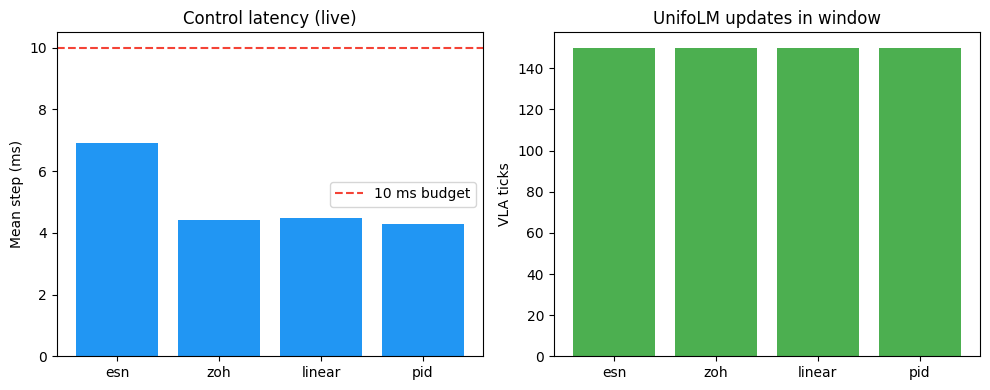

Figure: /home/aihimekpen/research_summer_2026/research/results/step3_dual_thread/dual_thread_summary_all_live.png
CSV:    /home/aihimekpen/research_summer_2026/research/results/step3_dual_thread/dual_thread_summary_all_live.csv


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

df = pd.DataFrame(reports)
cols = [
    "bridge",
    "mock_vla",
    "vla_ticks",
    "mean_step_ms",
    "max_step_ms_steady",
    "achieved_control_hz",
    "gil_bypass_ok",
]
display(df[cols])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(df["bridge"], df["mean_step_ms"], color="#2196F3")
axes[0].axhline(10.0, color="#F44336", ls="--", label="10 ms budget")
axes[0].set_ylabel("Mean step (ms)")
axes[0].set_title(f"Control latency ({vla_tag})")
axes[0].legend()
axes[1].bar(df["bridge"], df["vla_ticks"], color="#4CAF50")
axes[1].set_ylabel("VLA ticks")
axes[1].set_title("UnifoLM updates in window")
plt.tight_layout()
fig_path = out_dir / f"dual_thread_summary_all_{vla_tag}.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

summary_csv = out_dir / f"dual_thread_summary_all_{vla_tag}.csv"
df.to_csv(summary_csv, index=False)
print(f"Figure: {fig_path}")
print(f"CSV:    {summary_csv}")
